# RQ3 report plots

Plots for visualising RQ3 findings.

RQ3: What is the cross-domain generalization performance of a Spatio-Temporal Transformer trained on real-world data versus synthetic data when evaluated on both real-world and synthetic tests using ADE and FDE?


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/Users/nickgrebe/Desktop/DSAI_YEAR2/project_2-2_25-26_dsai_group-12").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import math

import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from Reporting.reporting_notebook_utils import (
    DOMAIN_COLORS,
    DOMAIN_LABELS,
    EFFECT_ORDER,
    HORIZON_ORDER,
    RQ3_METRIC_ORDER,
    TEST_ORDER,
    TRAIN_LABELS,
    TRAIN_ORDER,
    configure_notebook,
    horizon_file_label,
    horizon_label,
    load_rq3_outputs,
    metric_label,
    percent_ci,
    save_figure,
)

base_dir, figures_dir, plt = configure_notebook("rq3", font_size=10, display_width=160)
factorial, domain, posthoc, readiness, folds = load_rq3_outputs(base_dir)


Base directory: /Users/nickgrebe/Desktop/DSAI_YEAR2/project_2-2_25-26_dsai_group-12/Reporting/rq3
Figures directory: /Users/nickgrebe/Desktop/DSAI_YEAR2/project_2-2_25-26_dsai_group-12/Reporting/rq3/figures
Loaded RQ3 tables from /Users/nickgrebe/Desktop/DSAI_YEAR2/project_2-2_25-26_dsai_group-12/Reporting/rq3


## Factorial significance heatmap

Saved figures/rq3_factorial_significance_heatmap.png


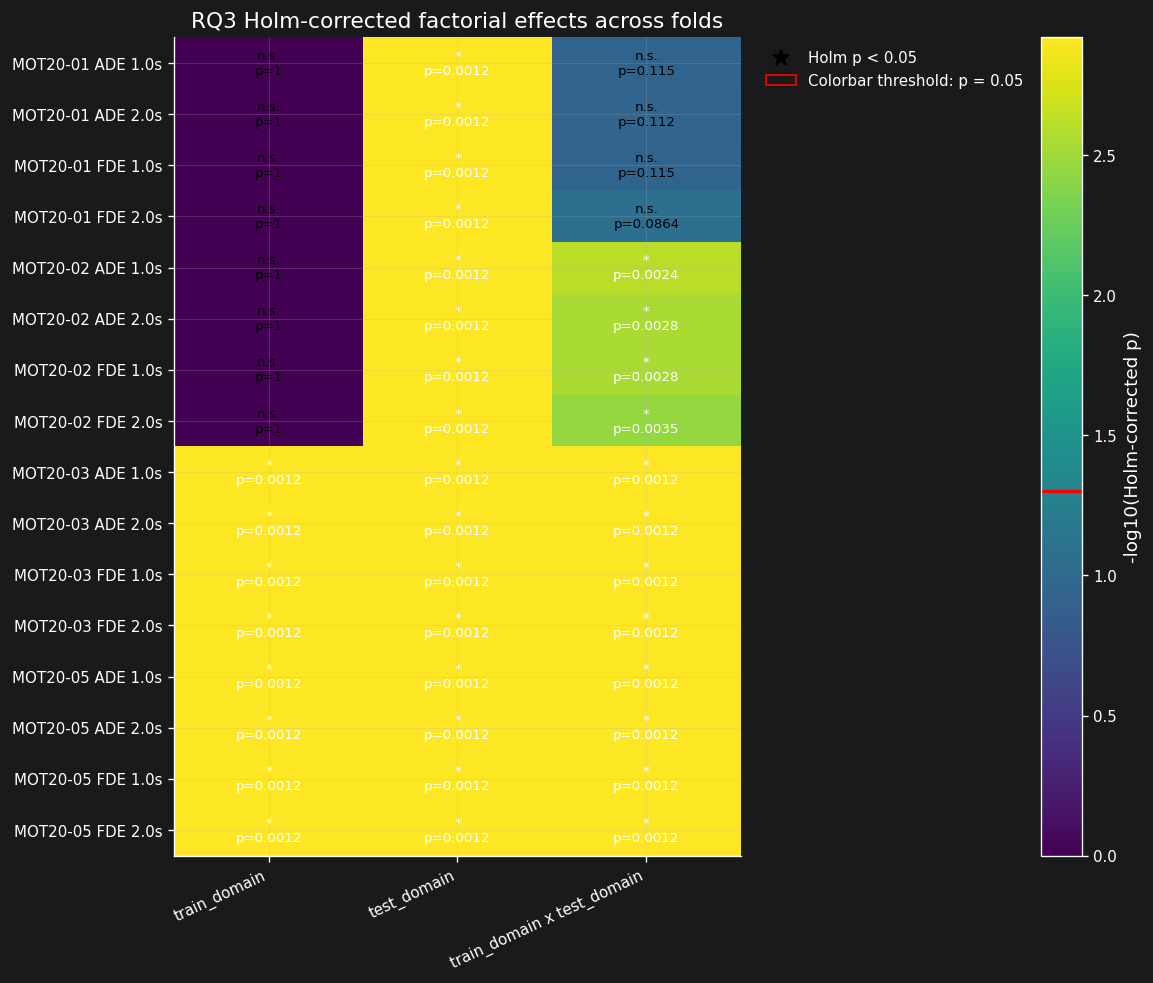

In [2]:
heatmap_rows = []
for fold in folds:
    for metric in RQ3_METRIC_ORDER:
        for horizon in HORIZON_ORDER:
            subset = factorial[(factorial["fold"] == fold) & (factorial["metric"] == metric) & (factorial["target_horizon_s"] == horizon)]
            for _, row in subset.iterrows():
                heatmap_rows.append({
                    "row_label": f"{fold} {metric_label(metric)} {horizon_label(horizon)}",
                    "effect": row["effect"],
                    "corrected_p_value": row["corrected_p_value"],
                    "significant": bool(row["significant"]),
                })

heatmap_df = pd.DataFrame(heatmap_rows)
row_order = heatmap_df["row_label"].drop_duplicates().tolist()
value_matrix = heatmap_df.pivot(index="row_label", columns="effect", values="corrected_p_value").reindex(index=row_order, columns=EFFECT_ORDER)
sig_matrix = heatmap_df.pivot(index="row_label", columns="effect", values="significant").reindex(index=row_order, columns=EFFECT_ORDER)
plot_values = -np.log10(value_matrix.clip(lower=1e-300))
threshold = -math.log10(0.05)

fig, ax = plt.subplots(figsize=(9.5, max(6, 0.38 * len(row_order) + 2)), constrained_layout=True)
im = ax.imshow(plot_values.values, aspect="auto", cmap="viridis", vmin=0)
ax.set_xticks(np.arange(len(EFFECT_ORDER)), [effect.replace(":", " x ") for effect in EFFECT_ORDER], rotation=25, ha="right")
ax.set_yticks(np.arange(len(row_order)), row_order)
ax.set_title("RQ3 Holm-corrected factorial effects across folds")

for i, row_label in enumerate(row_order):
    for j, effect in enumerate(EFFECT_ORDER):
        p_value = value_matrix.loc[row_label, effect]
        significant = bool(sig_matrix.loc[row_label, effect])
        text_color = "white" if plot_values.loc[row_label, effect] > max(1.4, threshold) else "black"
        ax.text(j, i, f"{'*' if significant else 'n.s.'}\np={p_value:.3g}", ha="center", va="center", color=text_color, fontsize=8)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("-log10(Holm-corrected p)")
cbar.ax.axhline(threshold, color="red", linewidth=2)
legend_handles = [
    Line2D([0], [0], marker="*", color="none", markerfacecolor="black", markeredgecolor="black", markersize=10, label="Holm p < 0.05"),
    Patch(facecolor="none", edgecolor="red", label="Colorbar threshold: p = 0.05"),
]
ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
save_figure(fig, figures_dir, base_dir, "rq3_factorial_significance_heatmap")
plt.show()


## 2x2 interaction pattern of mean ADE/FDE

Saved figures/rq3_interaction_ADE_1s.png


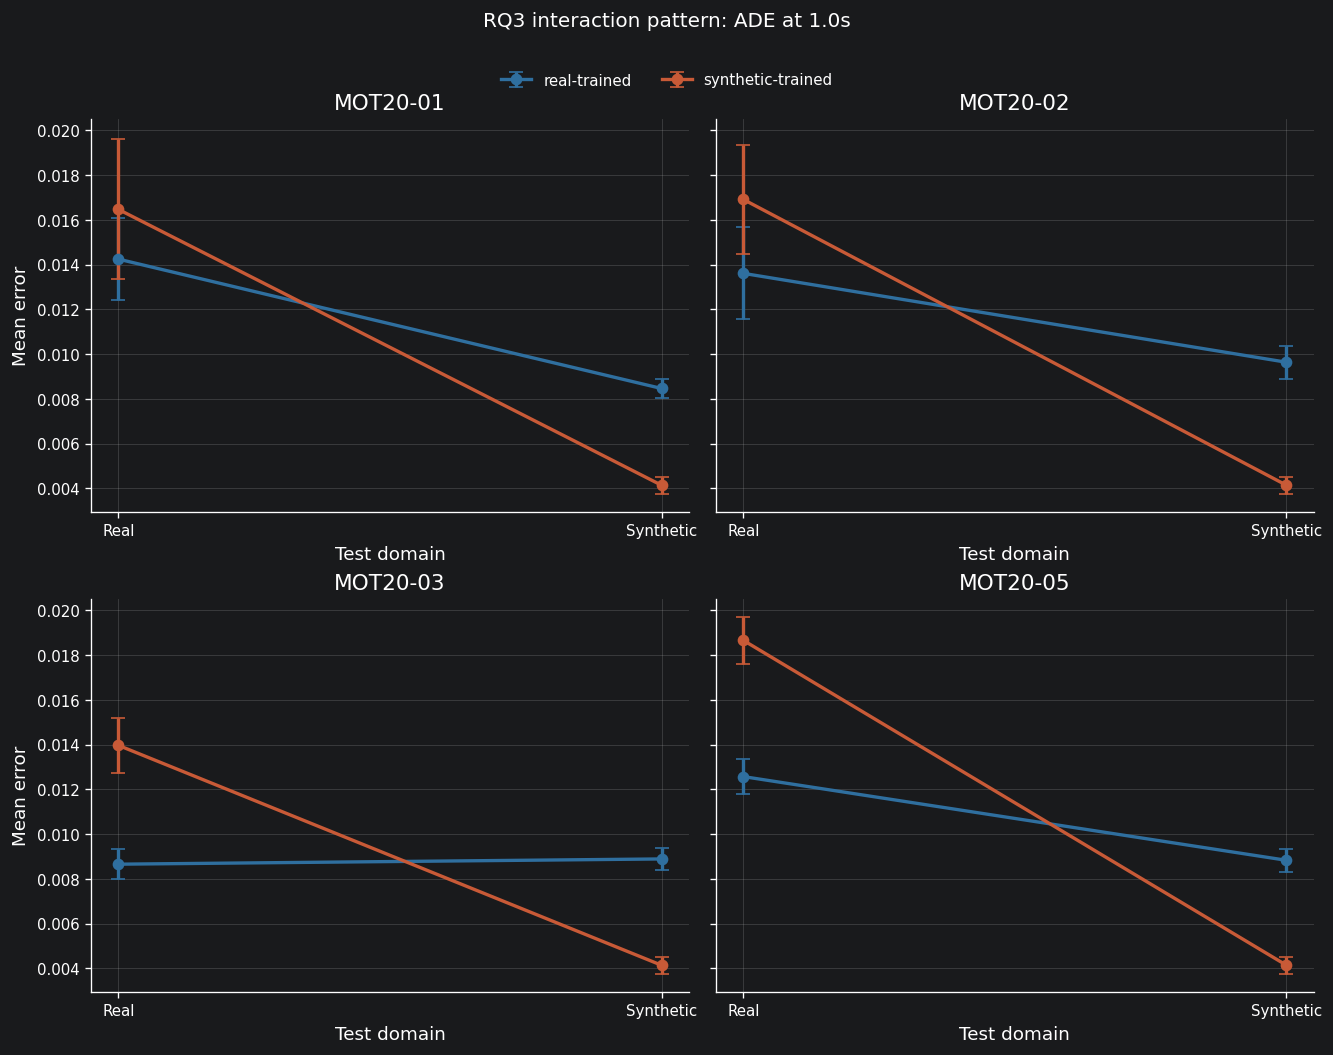

Saved figures/rq3_interaction_ADE_2s.png


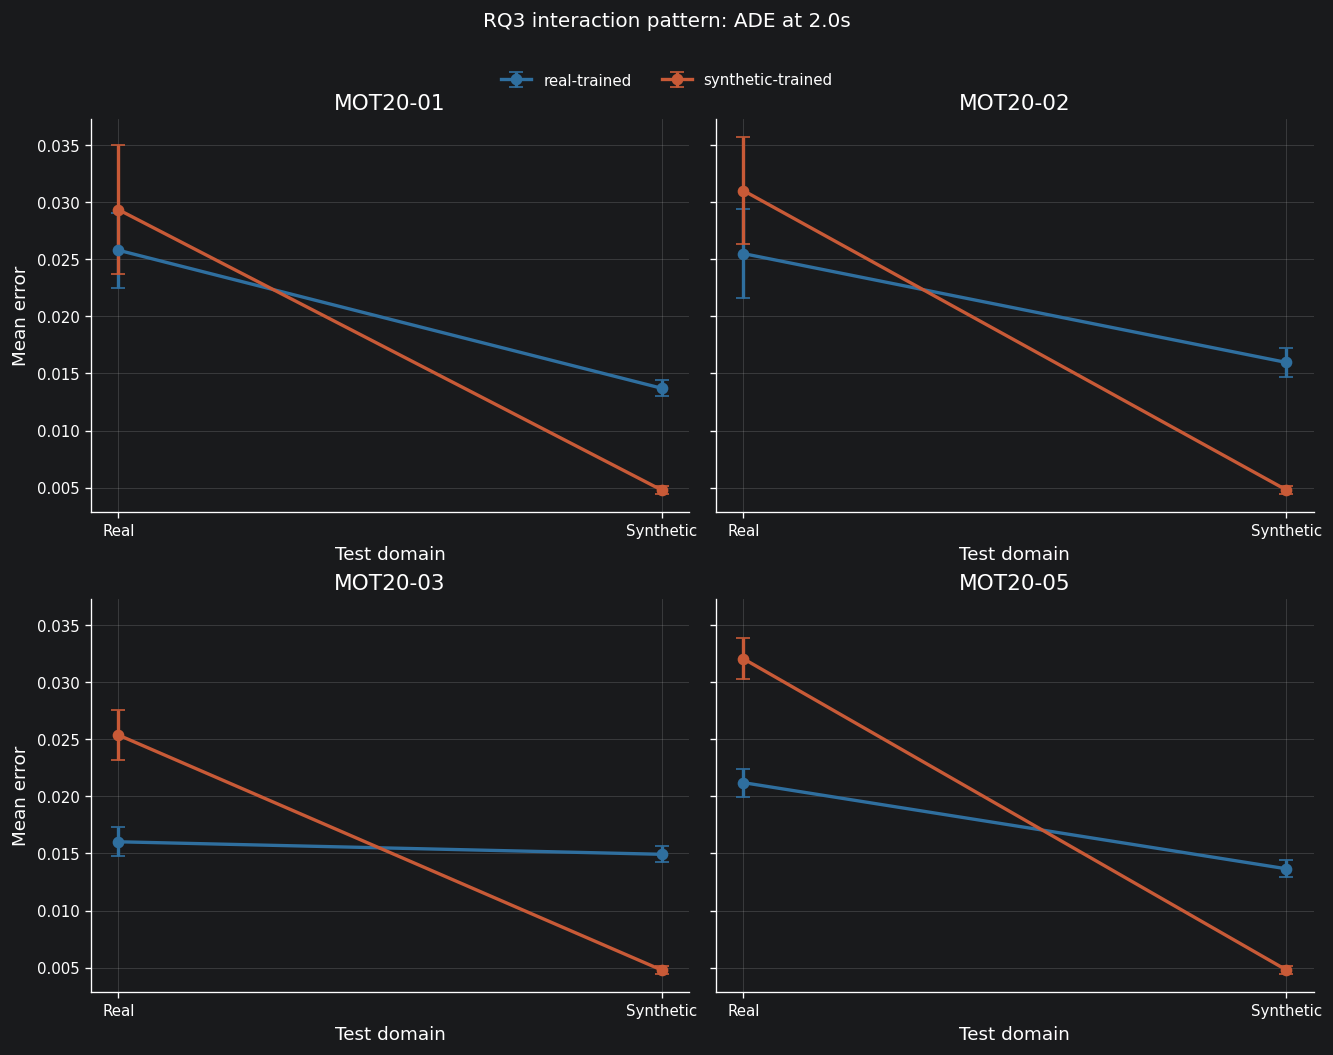

Saved figures/rq3_interaction_FDE_1s.png


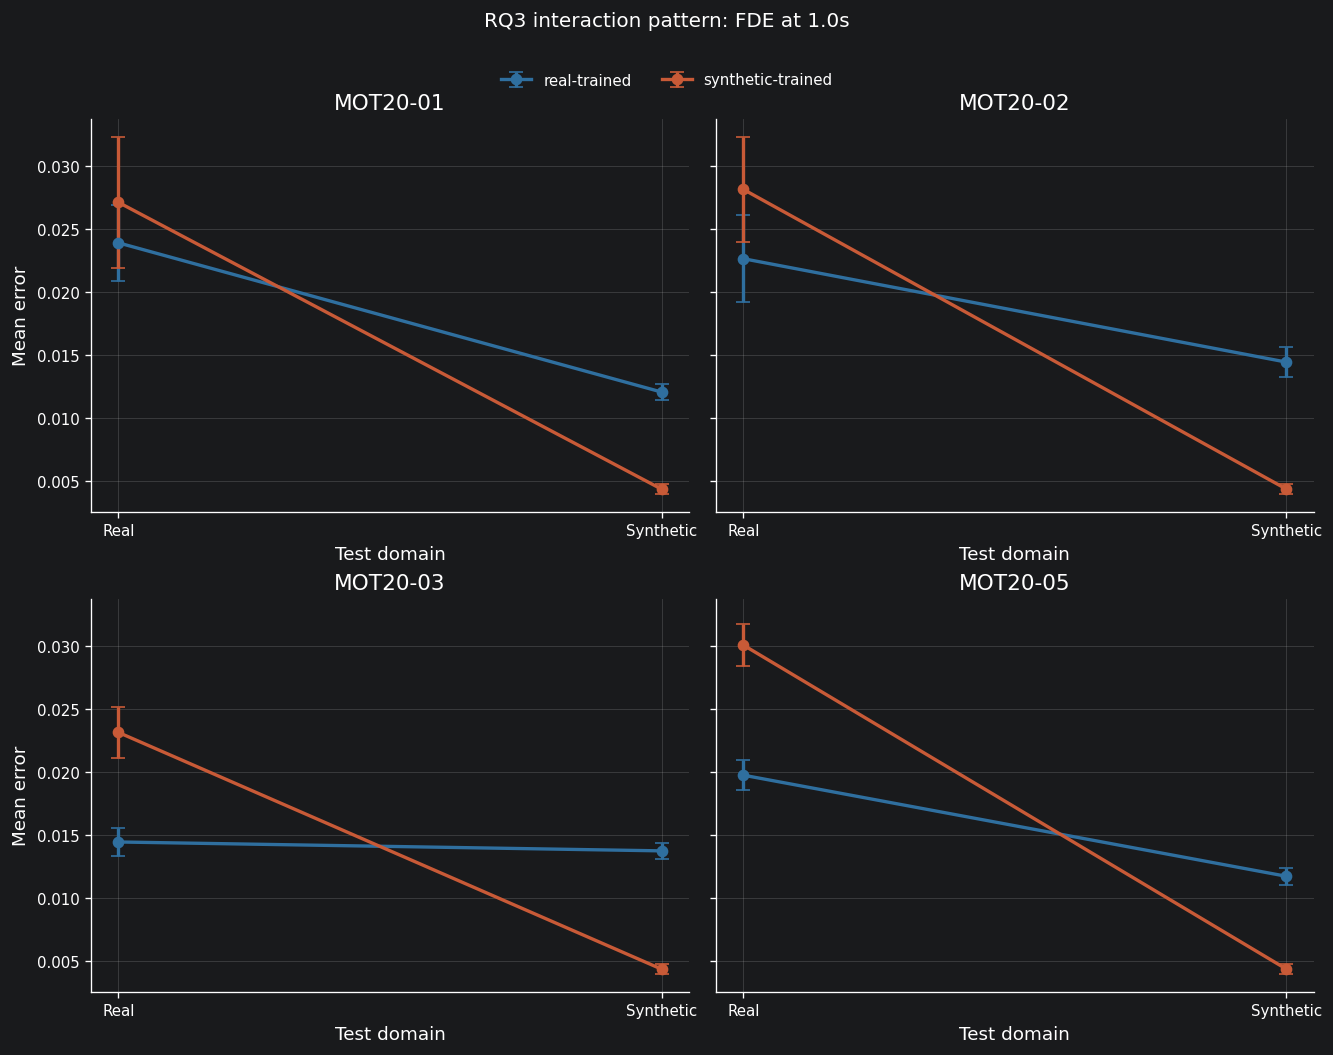

Saved figures/rq3_interaction_FDE_2s.png


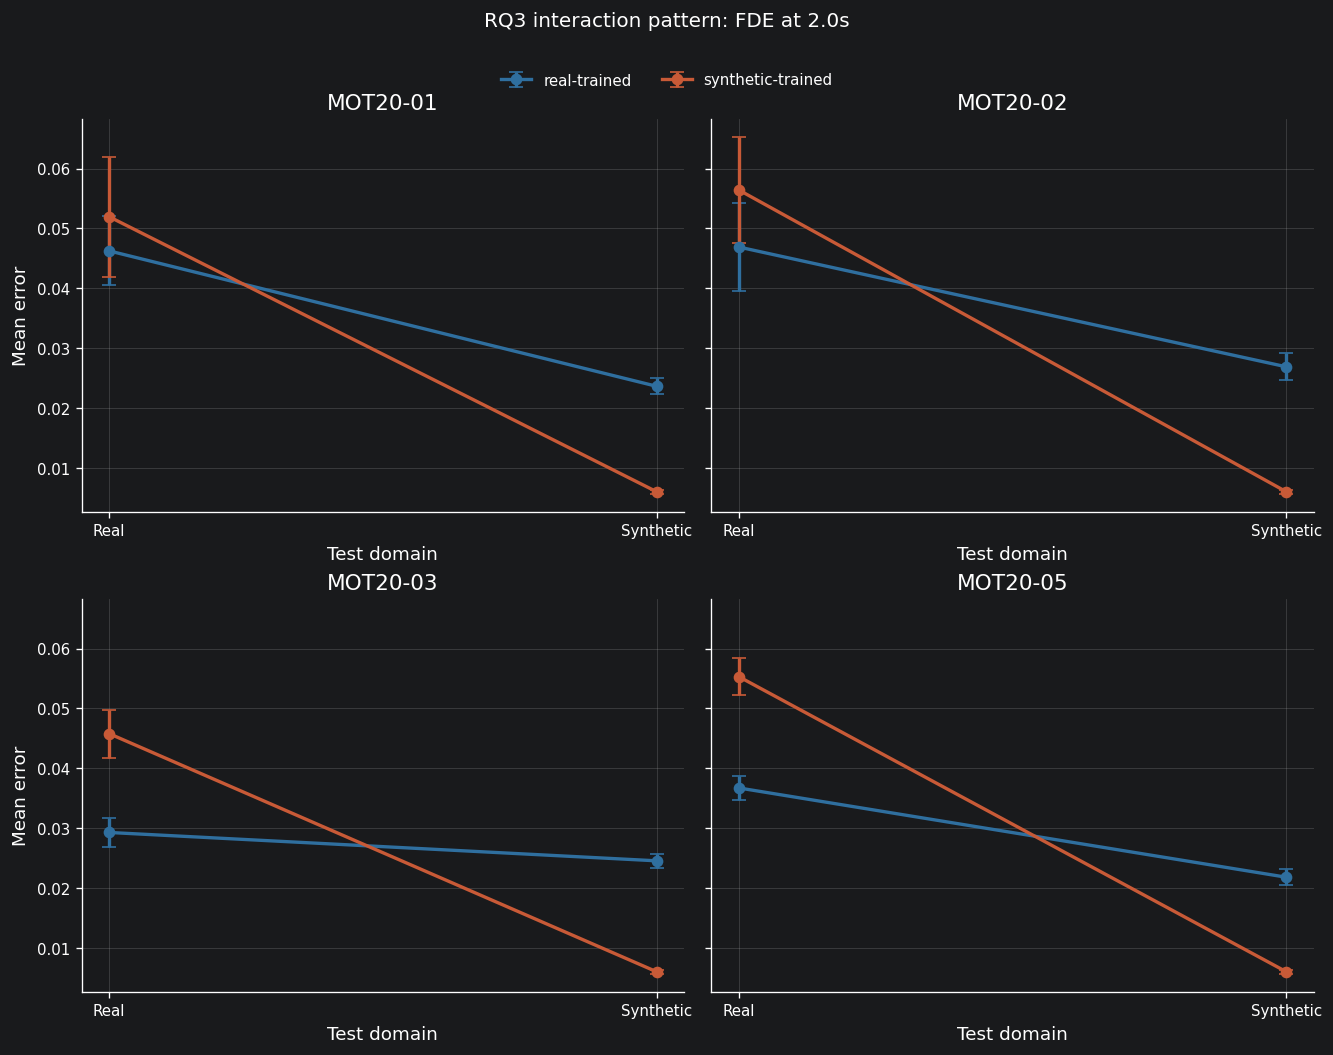

In [3]:
for metric in RQ3_METRIC_ORDER:
    for horizon in HORIZON_ORDER:
        subset = domain[(domain["metric"] == metric) & (domain["target_horizon_s"] == horizon)].copy()
        if subset.empty:
            continue

        fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True, constrained_layout=True)
        for ax, fold in zip(axes.ravel(), folds):
            fold_data = subset[subset["fold"] == fold]
            for train_domain in TRAIN_ORDER:
                train_data = fold_data[fold_data["train_domain"] == train_domain].set_index("test_domain").reindex(TEST_ORDER)
                y = train_data["mean_error"].to_numpy(dtype=float)
                if np.isnan(y).all():
                    continue
                yerr = np.vstack([y - train_data["ci_lower"].to_numpy(dtype=float), train_data["ci_upper"].to_numpy(dtype=float) - y])
                ax.errorbar(np.arange(len(TEST_ORDER)), y, yerr=yerr, marker="o", linewidth=2, capsize=4, color=DOMAIN_COLORS[train_domain], label=TRAIN_LABELS[train_domain])
            ax.set_title(fold)
            ax.set_xticks(np.arange(len(TEST_ORDER)), [DOMAIN_LABELS[test] for test in TEST_ORDER])
            ax.set_xlabel("Test domain")
        axes[0, 0].set_ylabel("Mean error")
        axes[1, 0].set_ylabel("Mean error")
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.03))
        fig.suptitle(f"RQ3 interaction pattern: {metric_label(metric)} at {horizon_label(horizon)}", y=1.08)
        save_figure(fig, figures_dir, base_dir, f"rq3_interaction_{metric_label(metric)}_{horizon_file_label(horizon)}")
        plt.show()


## Train-domain gap by test domain

Saved figures/rq3_real_test_train_gap.png


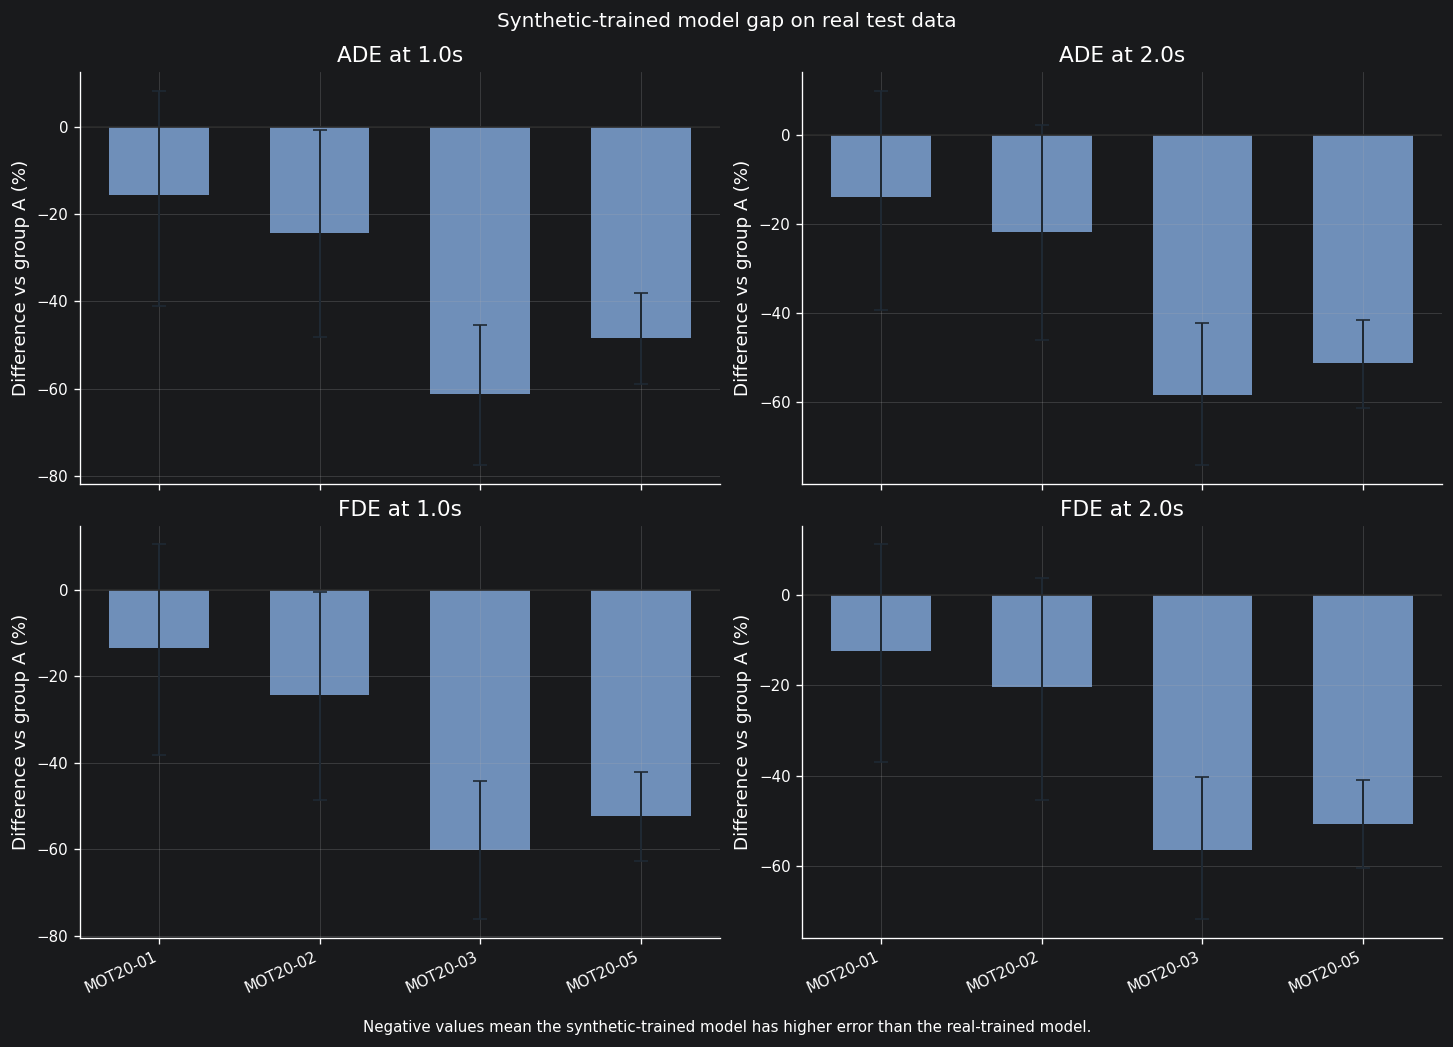

Saved figures/rq3_synthetic_test_train_gap.png


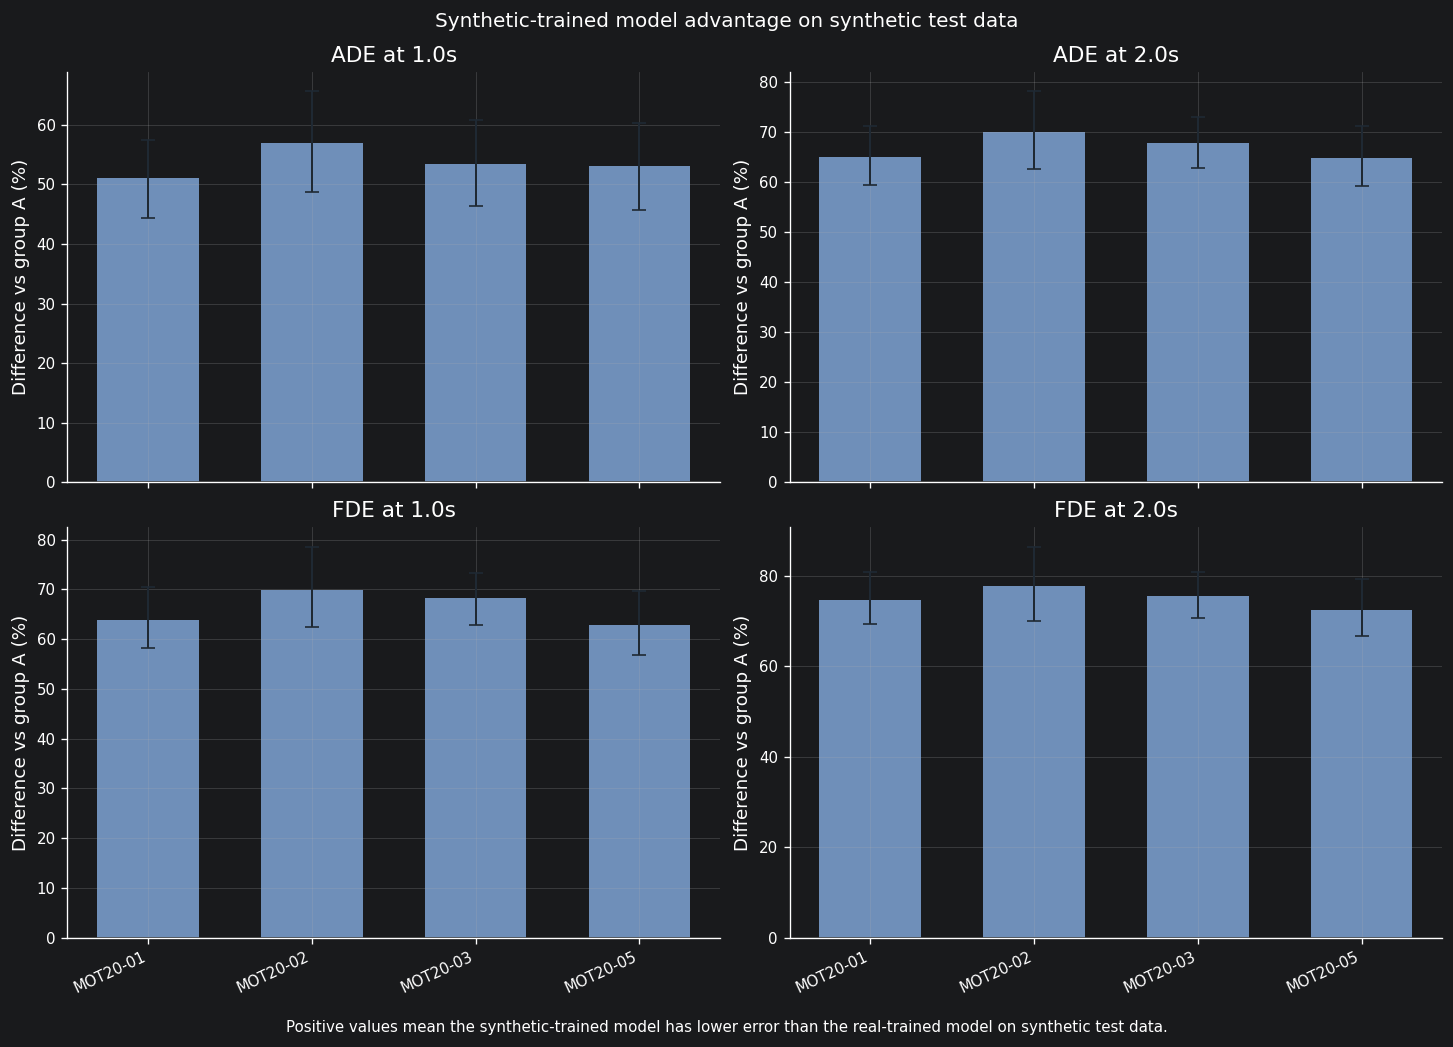

In [4]:
def plot_posthoc_gap(comparison, title, stem, y_note):
    subset = posthoc[posthoc["comparison"] == comparison].copy()
    if subset.empty:
        raise ValueError(f"No posthoc rows found for comparison={comparison}")

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, constrained_layout=True)
    for ax, metric, horizon in zip(axes.ravel(), [m for m in RQ3_METRIC_ORDER for _ in HORIZON_ORDER], HORIZON_ORDER * len(RQ3_METRIC_ORDER)):
        panel = subset[(subset["metric"] == metric) & (subset["target_horizon_s"] == horizon)].set_index("fold").reindex(folds).reset_index()
        y = panel["percent_difference_relative_to_a"].to_numpy(dtype=float)
        ci_percent = panel.apply(percent_ci, axis=1, result_type="expand")
        ci_percent.columns = ["ci_lower_pct", "ci_upper_pct"]
        yerr = np.vstack([y - ci_percent["ci_lower_pct"].to_numpy(dtype=float), ci_percent["ci_upper_pct"].to_numpy(dtype=float) - y])
        x = np.arange(len(folds))
        ax.bar(x, y, color="#6f8fb9", width=0.62)
        ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="#1f2933", capsize=4, linewidth=1.2)
        ax.axhline(0, color="#2b2b2b", linewidth=1)
        ax.set_title(f"{metric_label(metric)} at {horizon_label(horizon)}")
        ax.set_xticks(x, folds, rotation=25, ha="right")
        ax.set_ylabel("Difference vs group A (%)")
    fig.suptitle(title, y=1.03)
    fig.text(0.5, -0.02, y_note, ha="center", va="top", fontsize=9)
    save_figure(fig, figures_dir, base_dir, stem)
    plt.show()

plot_posthoc_gap(
    "real_vs_synthetic_train_on_real_test",
    "Synthetic-trained model gap on real test data",
    "rq3_real_test_train_gap",
    "Negative values mean the synthetic-trained model has higher error than the real-trained model.",
)
plot_posthoc_gap(
    "real_vs_synthetic_train_on_synthetic_test",
    "Synthetic-trained model advantage on synthetic test data",
    "rq3_synthetic_test_train_gap",
    "Positive values mean the synthetic-trained model has lower error than the real-trained model on synthetic test data.",
)


## Test-domain difficulty gap by train domain

Saved figures/rq3_test_domain_gap_by_train_domain.png


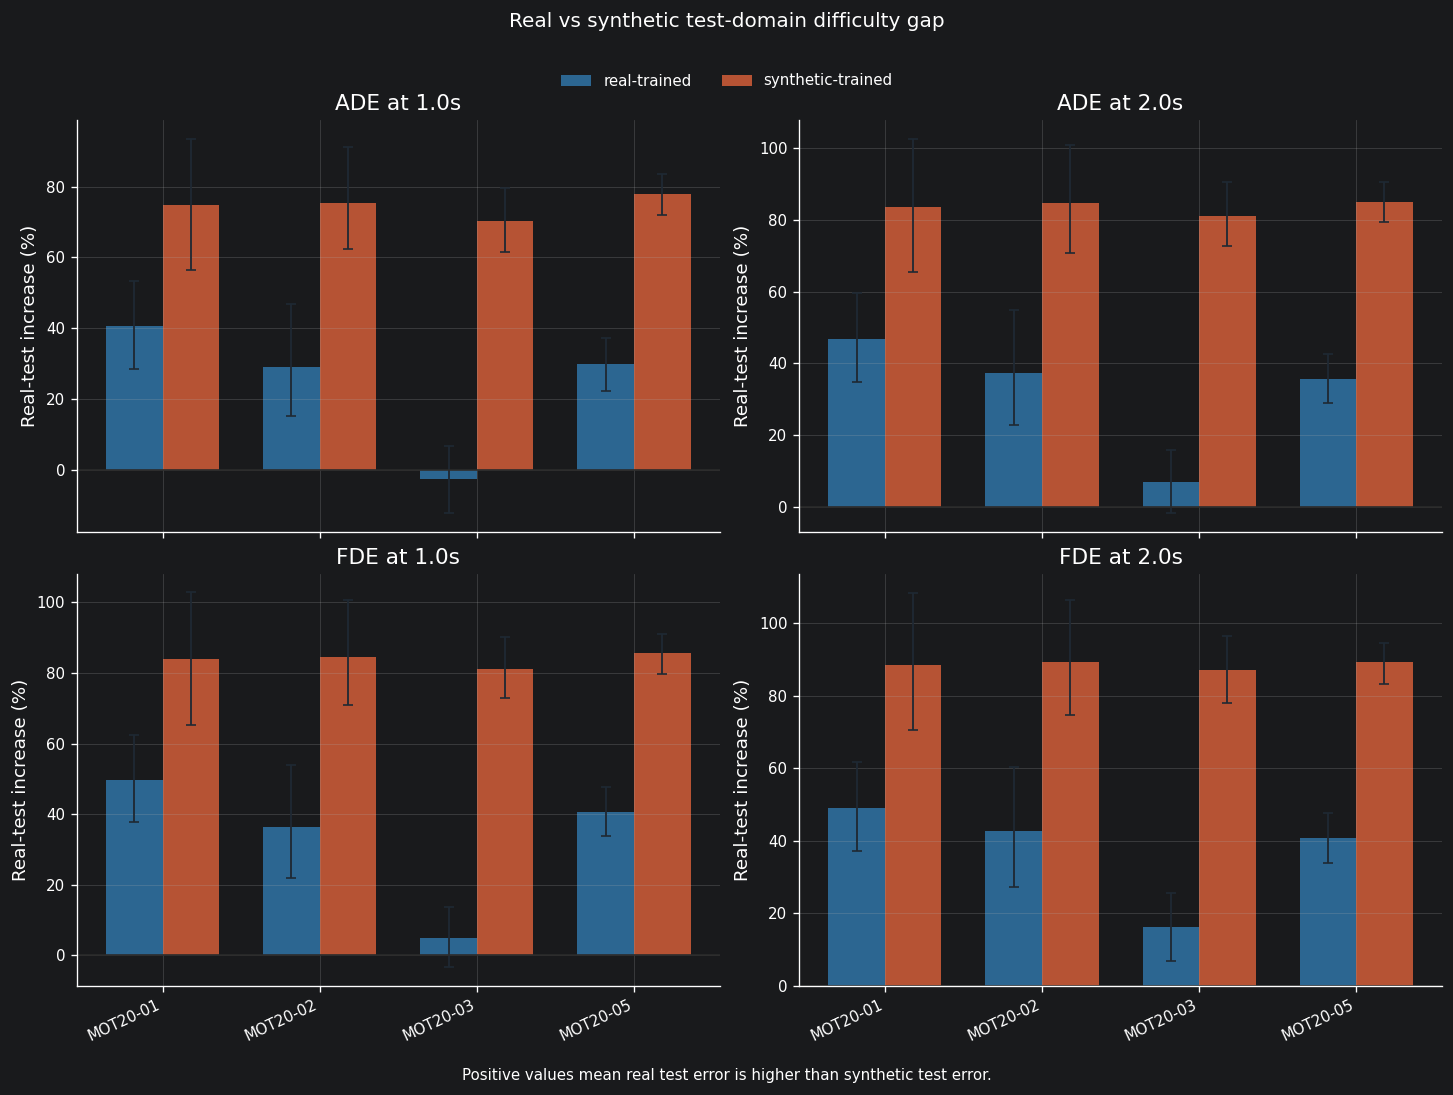

In [5]:
difficulty_comparisons = {
    "real": "real_vs_synthetic_test_for_real_train",
    "synthetic": "real_vs_synthetic_test_for_synthetic_train",
}
difficulty = posthoc[posthoc["comparison"].isin(difficulty_comparisons.values())].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, constrained_layout=True)
bar_width = 0.36
x = np.arange(len(folds))

for ax, metric, horizon in zip(axes.ravel(), [m for m in RQ3_METRIC_ORDER for _ in HORIZON_ORDER], HORIZON_ORDER * len(RQ3_METRIC_ORDER)):
    for offset_idx, train_domain in enumerate(TRAIN_ORDER):
        comparison = difficulty_comparisons[train_domain]
        panel = difficulty[(difficulty["metric"] == metric) & (difficulty["target_horizon_s"] == horizon) & (difficulty["comparison"] == comparison)].set_index("fold").reindex(folds).reset_index()
        y = panel["percent_difference_relative_to_a"].to_numpy(dtype=float)
        ci_percent = panel.apply(percent_ci, axis=1, result_type="expand")
        ci_percent.columns = ["ci_lower_pct", "ci_upper_pct"]
        positions = x + (offset_idx - 0.5) * bar_width
        ax.bar(positions, y, width=bar_width, color=DOMAIN_COLORS[train_domain], label=TRAIN_LABELS[train_domain], alpha=0.9)
        ax.errorbar(positions, y, yerr=np.vstack([y - ci_percent["ci_lower_pct"].to_numpy(dtype=float), ci_percent["ci_upper_pct"].to_numpy(dtype=float) - y]), fmt="none", ecolor="#1f2933", capsize=3, linewidth=1.1)
    ax.axhline(0, color="#2b2b2b", linewidth=1)
    ax.set_title(f"{metric_label(metric)} at {horizon_label(horizon)}")
    ax.set_xticks(x, folds, rotation=25, ha="right")
    ax.set_ylabel("Real-test increase (%)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Real vs synthetic test-domain difficulty gap", y=1.08)
fig.text(0.5, -0.02, "Positive values mean real test error is higher than synthetic test error.", ha="center", va="top", fontsize=9)
save_figure(fig, figures_dir, base_dir, "rq3_test_domain_gap_by_train_domain")
plt.show()
